# Analys av europeiska flygrutter

## Projektbeskrivning
Projektet analyserar data om europeiska flygrutter. Syftet är att undersöka destinationer, priser och flygfrekvens med hjälp av grundläggande Python.

## Inläsning av data 

I detta steg läser programmet in data från CSV-filen "europe_air_routes.csv".
CSV-filen innehåller information om europeiska flygrutter, till exempel avgånsort,destination, pris och flygfrekvens.

In [2]:
# Importerar csv-modulen för att kunna läsa och skriva CSV-filer
import csv 

## Läs in CSV-filen
Här läser programmet in data från CSV-filen.
Try/except används för att hantera ett fel om filen inte kan hittas.

In [3]:
rutter = [] 

try:
    fil = open ("europe_air_routes.csv", "r")
    lasare = csv.DictReader(fil)

    for rad in lasare:
        rutter.append(rad)

    fil.close()
    print("CSV-filen har lästs in.")

except FileNotFoundError:
    print("Filen kunde inte hittas.")

CSV-filen har lästs in.


## Kontroll av priser

Här kontrollerar jag det lägsta och högsta priset i datasetet innan jag skapar prisgränser.Datasetet inehåller numeriska värden i kolumnen "price", men valutan anges inte. Darför används prisuppgifterna endast för att undersöka datan och inte som en exakt prisjämförelse.

In [4]:
priser = []

for rad in rutter:
    priser.append(int(rad["price"]))

print("Lägsta pris:", min(priser))
print("Högsta pris:", max(priser))

Lägsta pris: 0
Högsta pris: 16100


In [5]:
print ("Första fem priser:")

for pris in priser[:5]:
    print(pris)

Första fem priser:
70
30
40
40
90


## Kontroll av ruttyp

Här använder programmet if, elif och else  för att kontrollera vilken typ av flygrutt det är.

In [4]:
avgangsland = rutter[0]["departure_country"] 
ankomstland = rutter[0]["arrival_airport_country"]   

print ("Avgångsland:", avgangsland)
print ("Ankomstland:", ankomstland) 

if avgangsland == ankomstland:
    print("Det är en inrikesrutt")  
elif ankomstland == "Sweden":
    print("Det är en internationell rutt till Sverige")
else:
    print("Det är en internationell rutt")

Avgångsland: Bosnia and Herzegovina
Ankomstland: Germany
Det är en internationell rutt


## Förstå funktionen

Här skapar jag en enkel funktion som hämtar avgångslandet från en flygrutt.

In [6]:
def hamta_avgangsland(rutt):
   return rutt["departure_country"]

land=hamta_avgangsland(rutter[0])
print(land)

Bosnia and Herzegovina


In [7]:
def hamta_ankomstland(rutt):
   return rutt["arrival_airport_country"]

land=hamta_ankomstland(rutter[0])
print(land)

Germany


In [9]:
def hamta_ruttyp(rutt):
    if rutt["departure_country"] == rutt["arrival_airport_country"]:
        return "Inrikesrutt"
    else:
        return "Internationell rutt"

ruttyp = hamta_ruttyp(rutter[0])
print(ruttyp)

Internationell rutt


In [12]:
def hamta_flyg_per_vecka(rutt):
    return rutt["flights_per_week"]

flyg_per_vecka = hamta_flyg_per_vecka(rutter[0])
print(flyg_per_vecka)

4


In [14]:
def hamta_ankomststad(rutt):
    return rutt["arrival_airport_city_name_en"]

ankomststad = hamta_ankomststad(rutter[0])
print(ankomststad)

Dortmund


## Klasser och Arv
Här skapar jag en basklass(föreldrar) för en flygrutt och en barnklass som ärver från basklass.

In [11]:
class Flygrutt:
    def __init__(self, avgangsland):
        self.avgangsland = avgangsland

    def visa_avgangsland(self):
        print(self.avgangsland)


class InternationellRutt(Flygrutt):
    def __init__(self,avgangsland,ankomstland):
        super().__init__(avgangsland)
        self.ankomstland = ankomstland

    def visa_ankomstland(self):
        print(self.ankomstland)


rutt1=InternationellRutt(
    rutter[0]["departure_country"],
    rutter[0]["arrival_airport_country"]
)   

rutt1.visa_avgangsland()
rutt1.visa_ankomstland()    

Bosnia and Herzegovina
Germany


## Visualisering med Matplotlib

Här använder jag det externa biblioteket Matlotlib för att visa antal flyg per vecka för fem flygrutter.

In [18]:
import matplotlib.pyplot as plt

In [20]:
stader = []
flyg = []

for rutt in rutter [:5]:
    stader.append(rutt["arrival_airport_city_name_en"])
    flyg.append(int(rutt["flights_per_week"]))

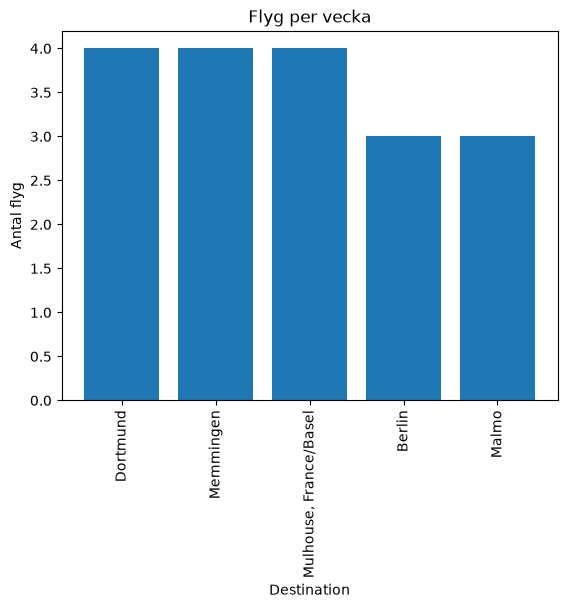

In [23]:
plt.bar(stader, flyg)

plt.title("Flyg per vecka")
plt.xlabel("Destination")
plt.ylabel("Antal flyg")

plt.xticks(rotation=90)

plt.show()